In [413]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [414]:
pd.set_option('display.max_columns', None)

In [415]:
PRED_INTERVAL = 14
TARGET_LABEL = "min_temp_F"

In [416]:
TRAIN_SET = "extended"
TRAIN_SAMPLE_STEP_SIZE = PRED_INTERVAL
INCLUDE_MONTH_FEATURE = True
VAL_SIZE_DAYS = 10 * PRED_INTERVAL

In [417]:
train_df_files = {
    "basic": "data/train.csv",
    "extended": "data/train_extended.csv"
}
full_train_df = pd.read_csv(train_df_files[TRAIN_SET])
test_df = pd.read_csv("data/test.csv")

for df in [full_train_df, test_df]:
    df.columns = ["date", "max_temp_F", TARGET_LABEL, "precipitation_inch", "snow_inch", "snow_depth_inch"]
    # df['day'] = np.arange(len(df))
    df['date'] = pd.to_datetime(df['date'])
    if INCLUDE_MONTH_FEATURE:
        df['month'] = df['date'].dt.day / 365 * 12

weather_cols = ["max_temp_F", TARGET_LABEL, "precipitation_inch", "snow_inch", "snow_depth_inch"]
for df in [full_train_df, test_df]:
    for col in weather_cols:
        for i in range(len(df)):
            if df[col].iloc[i] == "T":
                df.loc[i, col] = 0.01
            elif isinstance(df[col].iloc[i], str):
                df.loc[i, col] = float(df.loc[i, col])

feature_cols = weather_cols.copy()
if INCLUDE_MONTH_FEATURE:
    feature_cols.append("month")

full_train_df.head()

,date,max_temp_F,min_temp_F,precipitation_inch,snow_inch,snow_depth_inch,month
0,2010-01-01,6.0,-9.0,0.01,0.01,9.0,0.032877
1,2010-01-02,1.0,-15.0,0.0,0.0,9.0,0.065753
2,2010-01-03,7.0,-14.0,0.0,0.0,9.0,0.098630
3,2010-01-04,7.0,-10.0,0.0,0.0,9.0,0.131507
4,2010-01-05,10.0,-9.0,0.0,0.0,9.0,0.164384


In [418]:
train_df = full_train_df.iloc[:-VAL_SIZE_DAYS].copy()
val_df = full_train_df.tail(VAL_SIZE_DAYS).copy()
print(f"Train set interval: {train_df['date'].min().date()} to {train_df['date'].max().date()}")
print(f"Validation set interval: {val_df['date'].min().date()} to {val_df['date'].max().date()}")

Train set interval: 2010-01-01 to 2025-08-03
Validation set interval: 2025-08-04 to 2025-12-21


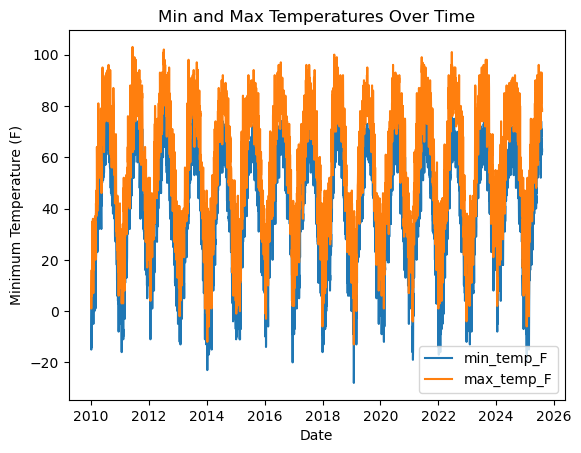

In [419]:
fig, ax = plt.subplots()
ax.plot('date', 'min_temp_F', data=train_df)
ax.plot('date', 'max_temp_F', data=train_df)
ax.set_title('Min and Max Temperatures Over Time');
ax.set_xlabel('Date')
ax.set_ylabel('Minimum Temperature (F)')
ax.legend()

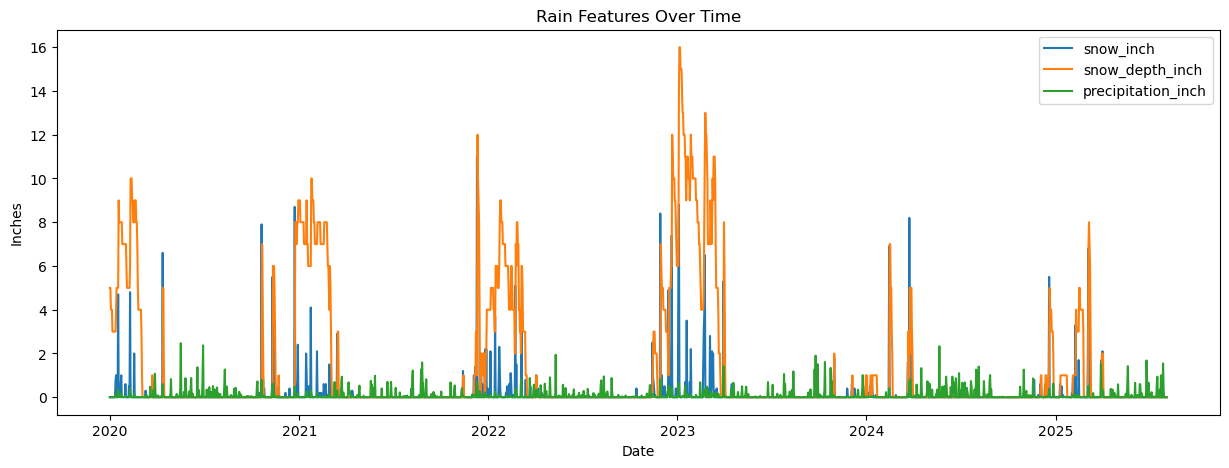

In [420]:
date_range = ("2020-01-01", "2025-12-31")
fig, ax = plt.subplots()
fig.set_size_inches(15, 5)
rain_features = ['snow_inch', 'snow_depth_inch', 'precipitation_inch']
for feature in rain_features:
    ax.plot('date', feature, data=train_df[(train_df['date'] >= date_range[0]) & (train_df['date'] <= date_range[1])], label=feature)
ax.set_title('Rain Features Over Time');
ax.set_xlabel('Date')
ax.set_ylabel('Inches')
ax.legend()

In [421]:
def create_dataset(df, step_size=1):
    x_list, y_list = [], []

    for i in range(0, len(df) - PRED_INTERVAL, step_size):
        x = df[feature_cols].iloc[i: i + PRED_INTERVAL]
        y = df[TARGET_LABEL].iloc[i + PRED_INTERVAL]
        # Here we convert to a numpy array and flatten so each variable from each day is its own feature
        # Using the difference from the previous day might also be helpful here
        x_list.append(np.array(x).flatten())
        y_list.append(y)
    return np.array(x_list), np.array(y_list)

X_train, y_train = create_dataset(train_df, TRAIN_SAMPLE_STEP_SIZE)
X_val, y_val = create_dataset(val_df, 1)

In [422]:
def fit_model(X_train, y_train):
    model = LinearRegression().fit(X_train, y_train)
    return model

model = fit_model(X_train, y_train)

In [423]:
def validation_mae(model, df, step_size=1):
    sequences = []
    n_rows = len(df)
    
    # Slide window through DataFrame
    for start_idx in range(0, n_rows - PRED_INTERVAL, step_size):
        end_idx = start_idx + PRED_INTERVAL
        subsequence = np.array(df[feature_cols].iloc[start_idx:end_idx]).flatten()
        sequences.append(subsequence)

    X = np.array(sequences)
    y_true = np.array(df[TARGET_LABEL].iloc[PRED_INTERVAL::step_size])
    mask = np.abs(y_true) > 10e-4
    y_true = y_true[mask]
    y_pred = model.predict(X)[mask]
    mae = np.mean(np.abs((y_true - y_pred) / y_true))
    return mae.item()

mae = validation_mae(model, val_df, step_size=PRED_INTERVAL)
mae

0.0770157595469917

In [424]:
def make_submission(df):
    X_train, y_train = create_dataset(full_train_df, TRAIN_SAMPLE_STEP_SIZE)
    model = fit_model(X_train, y_train)
    result_df = pd.DataFrame(columns=["ID", 'Minimum Temperature degrees (F)'])

    for i in range(0, len(df), PRED_INTERVAL):
        x = df[feature_cols].iloc[i: i + PRED_INTERVAL]
        y = model.predict(np.array(x).flatten().reshape(1, -1))[0]
        result_df.loc[len(result_df)] = [int(i / PRED_INTERVAL), y]
    
    return result_df

submission = make_submission(test_df)
submission.to_csv("submission.csv", index=False)
submission

,ID,Minimum Temperature degrees (F)
0,0.0,55.449433
1,1.0,43.934145
2,2.0,57.584301
3,3.0,65.476967
4,4.0,68.647752
5,5.0,62.863746
6,6.0,60.082493
7,7.0,70.394799
8,8.0,48.920879
9,9.0,63.759745
